In [1]:
import pandas as pd
import matplotlib.pyplot as plt

aapl = pd.read_csv(
    "../data/processed/AAPL.csv",
    parse_dates=["Date"],
    index_col="Date"
)

aapl.head()

,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,24.171751,24.638251,23.733992,24.627196,212818400
2015-01-05,23.490799,24.021415,23.305084,23.941822,257142000
2015-01-06,23.493013,23.751688,23.132636,23.554918,263188400
2015-01-07,23.822445,23.921935,23.590300,23.700845,160423600
2015-01-08,24.737745,24.795229,24.032468,24.149647,237458000


In [2]:
aapl.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2938 entries, 2015-01-02 to 2026-09-09
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2938 non-null   float64
 1   High    2938 non-null   float64
 2   Low     2938 non-null   float64
 3   Open    2938 non-null   float64
 4   Volume  2938 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 137.7 KB


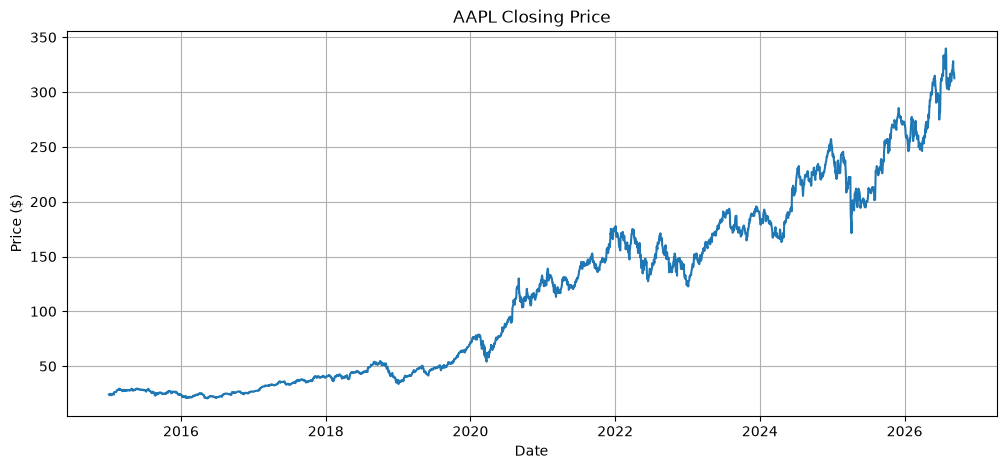

In [3]:
plt.figure(figsize=(12, 5))

plt.plot(aapl.index, aapl["Close"])

plt.title("AAPL Closing Price")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.grid(True)

plt.show()

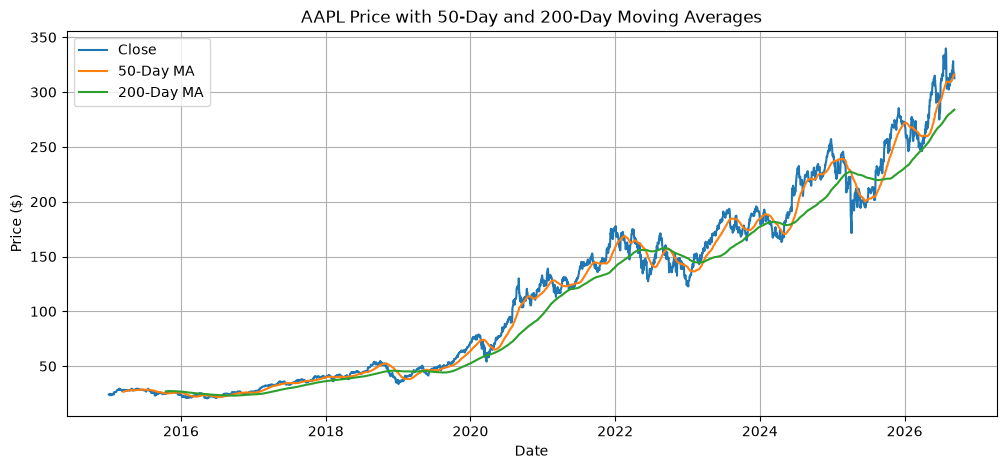

In [4]:
aapl["MA50"] = aapl["Close"].rolling(50).mean()
aapl["MA200"] = aapl["Close"].rolling(200).mean()

plt.figure(figsize=(12, 5))

plt.plot(aapl.index, aapl["Close"], label="Close")
plt.plot(aapl.index, aapl["MA50"], label="50-Day MA")
plt.plot(aapl.index, aapl["MA200"], label="200-Day MA")

plt.title("AAPL Price with 50-Day and 200-Day Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(True)

plt.show()

In [5]:
aapl["Return"] = aapl["Close"].pct_change()

aapl["Return"].describe()

count    2937.000000
mean        0.001036
std         0.018107
min        -0.128647
25%        -0.007395
50%         0.000988
75%         0.010001
max         0.153289
Name: Return, dtype: float64

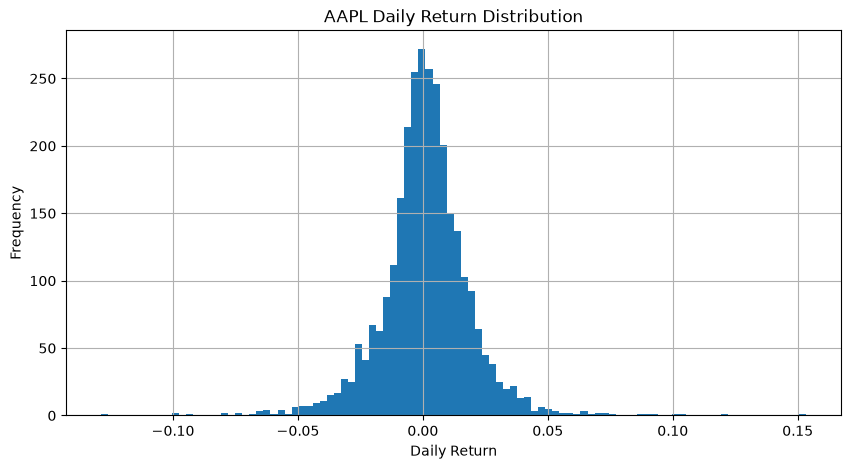

In [6]:
plt.figure(figsize=(10, 5))

plt.hist(aapl["Return"].dropna(), bins=100)

plt.title("AAPL Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.grid(True)

plt.show()

In [7]:
print("Skewness:", aapl["Return"].skew())
print("Kurtosis:", aapl["Return"].kurtosis())

Skewness: 0.10584742975499563
Kurtosis: 6.410653183786064


In [8]:
from scipy.stats import jarque_bera

jb_stat, p_value = jarque_bera(aapl["Return"].dropna())

print("Jarque-Bera statistic:", jb_stat)
print("p-value:", p_value)

Jarque-Bera statistic: 5014.36055323192
p-value: 0.0


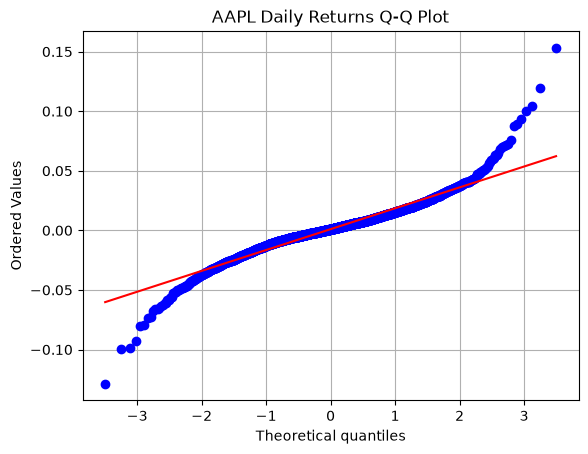

In [9]:
import scipy.stats as stats

stats.probplot(
    aapl["Return"].dropna(),
    dist="norm",
    plot=plt
)

plt.title("AAPL Daily Returns Q-Q Plot")
plt.grid(True)

plt.show()

In [10]:
daily_volatility = aapl["Return"].std()
annualized_volatility = daily_volatility * (252 ** 0.5)

print("Daily volatility:", daily_volatility)
print("Annualized volatility:", annualized_volatility)

Daily volatility: 0.01810671138617572
Annualized volatility: 0.2874351323342554


In [11]:
from statsmodels.tsa.stattools import adfuller

price_adf = adfuller(aapl["Close"].dropna())
return_adf = adfuller(aapl["Return"].dropna())

print("ADF Test - Price")
print("ADF Statistic:", price_adf[0])
print("p-value:", price_adf[1])

print("\nADF Test - Daily Returns")
print("ADF Statistic:", return_adf[0])
print("p-value:", return_adf[1])

ADF Test - Price
ADF Statistic: 0.6874091178104742
p-value: 0.98958321833936

ADF Test - Daily Returns
ADF Statistic: -17.60487952899897
p-value: 3.90514002879047e-30


/var/folders/h4/xfhkq8md47xf1871fbd5m3dm0000gn/T/ipykernel_10173/1648836900.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  price_adf = adfuller(aapl["Close"].dropna())
/var/folders/h4/xfhkq8md47xf1871fbd5m3dm0000gn/T/ipykernel_10173/1648836900.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return_adf = adfuller(aapl["Return"].dropna())


In [12]:
print("Pearson Correlation:")
print(aapl[["Close", "Volume", "Return"]].corr(method="pearson"))

print("\nSpearman Correlation:")
print(aapl[["Close", "Volume", "Return"]].corr(method="spearman"))

Pearson Correlation:
           Close    Volume    Return
Close   1.000000 -0.587499  0.009837
Volume -0.587499  1.000000 -0.047398
Return  0.009837 -0.047398  1.000000

Spearman Correlation:
           Close    Volume    Return
Close   1.000000 -0.746633  0.015296
Volume -0.746633  1.000000 -0.019788
Return  0.015296 -0.019788  1.000000


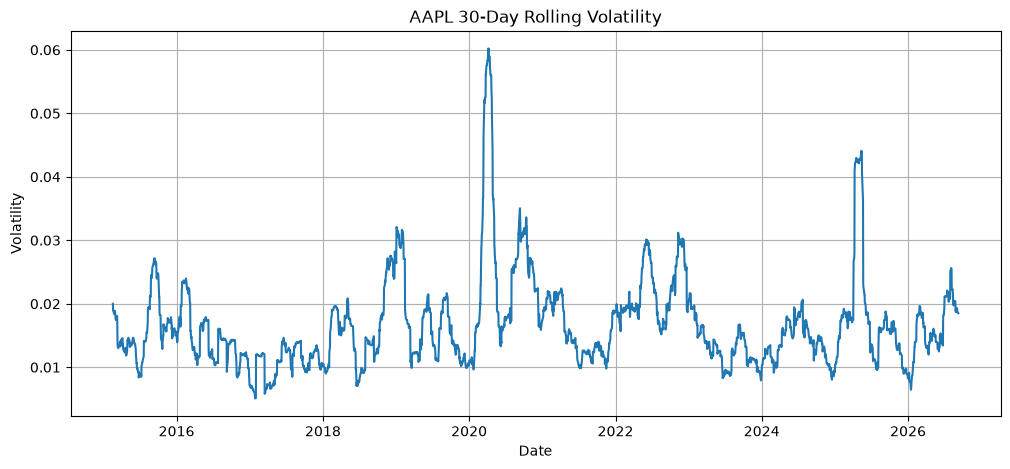

In [13]:
aapl["RollingVol_30"] = aapl["Return"].rolling(30).std()

plt.figure(figsize=(12, 5))

plt.plot(aapl.index, aapl["RollingVol_30"])

plt.title("AAPL 30-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.grid(True)

plt.show()

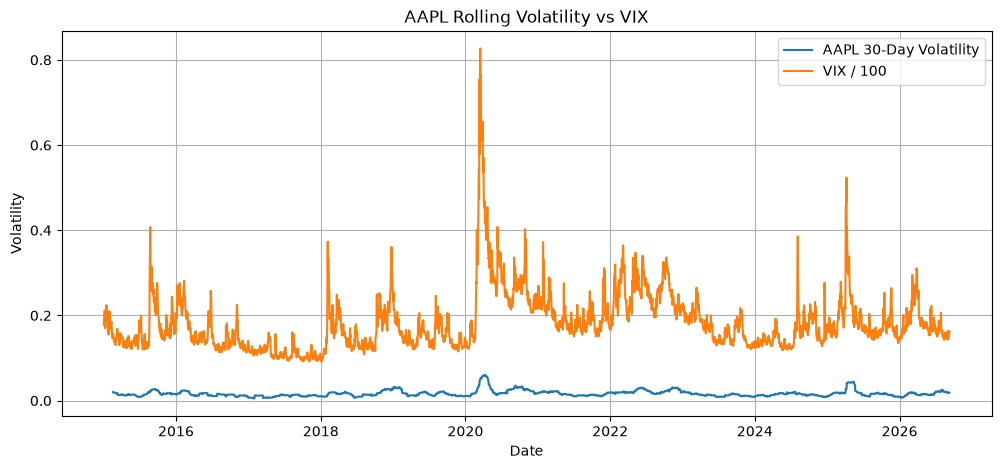

In [14]:
vix = pd.read_csv(
    "../data/processed/VIX.csv",
    parse_dates=["Date"],
    index_col="Date"
)

plt.figure(figsize=(12, 5))

plt.plot(aapl.index, aapl["RollingVol_30"], label="AAPL 30-Day Volatility")
plt.plot(vix.index, vix["Close"] / 100, label="VIX / 100")

plt.title("AAPL Rolling Volatility vs VIX")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.grid(True)

plt.show()

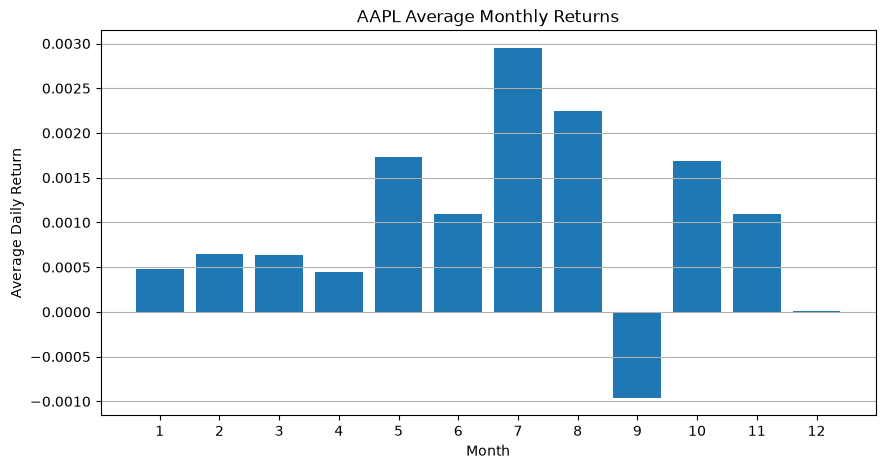

In [15]:
aapl["Month"] = aapl.index.month

monthly_returns = aapl.groupby("Month")["Return"].mean()

plt.figure(figsize=(10, 5))

plt.bar(monthly_returns.index, monthly_returns.values)

plt.title("AAPL Average Monthly Returns")
plt.xlabel("Month")
plt.ylabel("Average Daily Return")
plt.xticks(range(1, 13))
plt.grid(axis="y")

plt.show()

## EDA Findings

- AAPL price is non-stationary according to the ADF test, while daily returns are stationary.
- Daily returns have a mean close to zero and show relatively high kurtosis, indicating heavy tails.
- The Q-Q plot shows clear deviations from normality, particularly in the tails.
- AAPL price and volume have a strong negative correlation in this dataset, while daily returns have very weak linear and rank correlations with volume.
- Rolling volatility shows volatility clustering, with large spikes during periods of market stress.
- AAPL volatility tends to increase during periods when the VIX is elevated.
- Monthly average returns show some variation across calendar months, suggesting possible seasonality.
- These findings support using returns and volatility-related features rather than modelling raw prices alone, while also motivating robust models that can handle non-normal return distributions.